##Import Required Libraries



In [128]:
import pandas as pd
import numpy as np

## Load the Dataset

In [129]:
df = pd.read_csv("../data/Crop_recommendation.csv")

##Preview the Dataset


In [130]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


##Understand the Dataset Structure

In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


##Check for Missing Values

In [132]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

##Check for Duplicate Rows

In [133]:
df.duplicated().sum()

np.int64(0)

##Examine the Target Classe

In [134]:
df["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

##Statistical Summary of the Dataset

In [135]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


##Separate Features and Target

In [136]:
X = df.drop("label", axis=1)
y = df["label"]

##Display Features and Target

In [137]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2200, 7)
y shape: (2200,)


##Display the Column Names


In [138]:
print(X.columns.tolist())

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [139]:
from sklearn.model_selection import train_test_split

##Split the Dataset into Training and Testing Sets

In [140]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##Check the Training and Testing Data

In [141]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (1760, 7)
Testing features: (440, 7)
Training labels: (1760,)
Testing labels: (440,)


## Import Required Machine Learning Algorithms and Metrics

In [142]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

##Create Multiple Machine Learning Models for Comparison

In [143]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

##Model Comparison Based on Accuracy

In [144]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, predictions)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
2,Random Forest,0.995455
3,Gradient Boosting,0.988636
1,Decision Tree,0.979545
0,Logistic Regression,0.972727


##dentify the Best Model from Model Comparison Results

In [145]:
best_model_name = results_df.iloc[0]["Model"]

print("Best model:", best_model_name)

Best model: Random Forest


## Select and Display the Best Mode

In [146]:
best_model = models[best_model_name]

print(best_model)

RandomForestClassifier(n_estimators=200, random_state=42)


## Generate and Visualize the Confusion Matrix

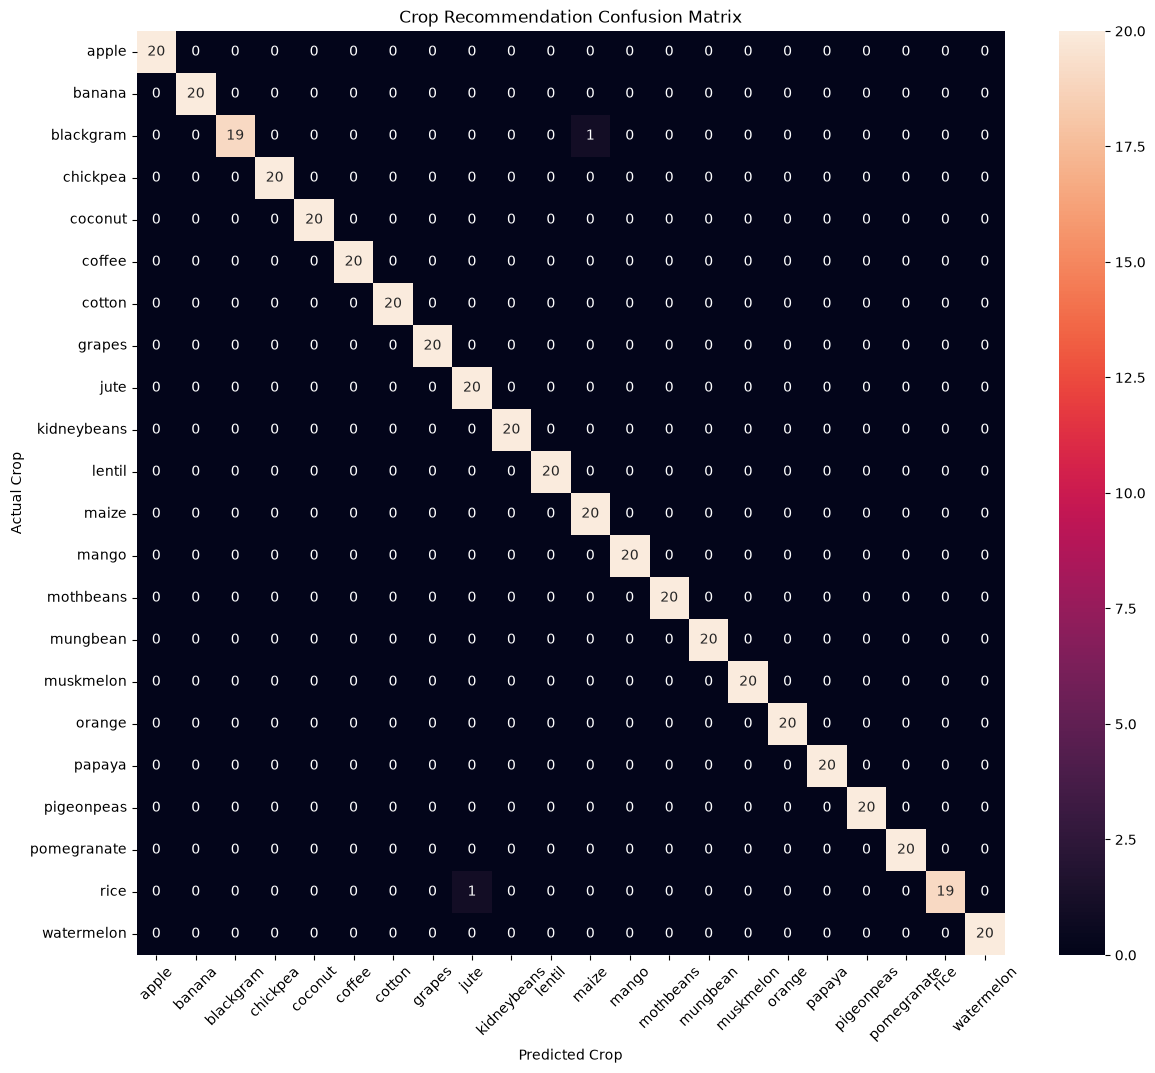

In [147]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=best_model.classes_,
    yticklabels=best_model.classes_
)

plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.title("Crop Recommendation Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## Calculate and Rank Feature Importance

In [148]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print(feature_importance)
else:
    print("Feature importance is not available for this model.")

       Feature  Importance
6     rainfall    0.219641
4     humidity    0.217058
2            K    0.180813
1            P    0.151342
0            N    0.103356
3  temperature    0.075485
5           ph    0.052305


## Visualize Feature Importance

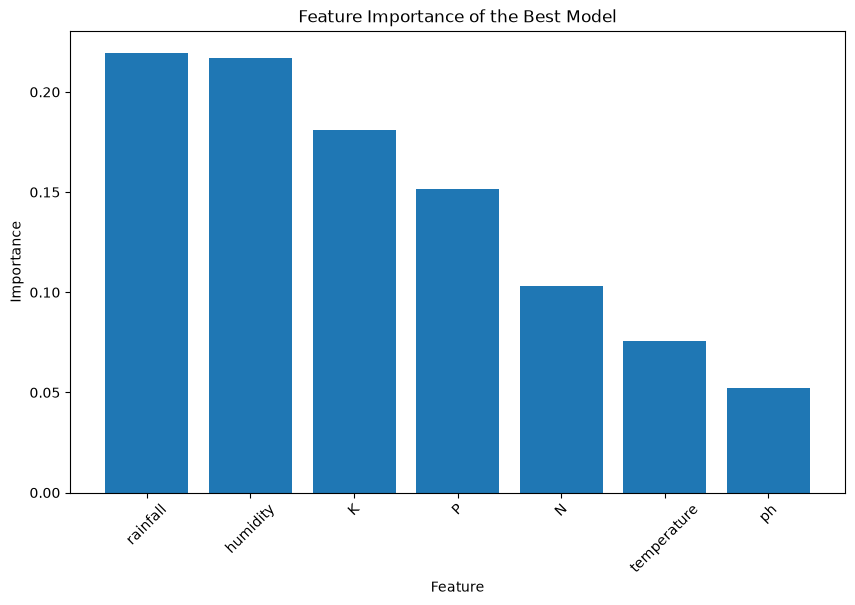

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance of the Best Model")

plt.xticks(rotation=45)

plt.show()

## Display Feature Importance as Percentages

In [150]:
feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
).round(2)

feature_importance

,Feature,Importance,Importance (%)
6,rainfall,0.219641,21.96
4,humidity,0.217058,21.71
2,K,0.180813,18.08
1,P,0.151342,15.13
0,N,0.103356,10.34
3,temperature,0.075485,7.55
5,ph,0.052305,5.23


## Identify the Most Influential Feature in the Best Model

In [151]:
most_important_feature = feature_importance.iloc[0]

print("Most Important Feature:", most_important_feature["Feature"])
print("Importance:", most_important_feature["Importance (%)"], "%")

Most Important Feature: rainfall
Importance: 21.96 %


## Report the Most Important Feature

In [152]:
feature_name = most_important_feature["Feature"]
importance_value = most_important_feature["Importance (%)"]

print(
    f"The most important feature is {feature_name}, "
    f"with an importance of {importance_value}%."
)

The most important feature is rainfall, with an importance of 21.96%.


## Save Feature Importance Results

In [153]:
feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


## Test the Best Model on a Sample from the Test Dataset


In [154]:
predicted_label = prediction[0]

print("Predicted Crop:", predicted_label)

Predicted Crop: orange


##Prediction Probabilities

In [155]:
probabilities = best_model.predict_proba(sample)

print("Prediction Probabilities:")
print(probabilities[0])

Prediction Probabilities:
[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.975 0.    0.    0.025 0.    0.   ]


##Display Prediction Probabilities for Each Crop Class

In [156]:
class_names = best_model.classes_

for class_name, probability in zip(class_names, probabilities[0]):
    if probability > 0:
        print(f"{class_name}: {probability * 100:.2f}%")

orange: 97.50%
pomegranate: 2.50%


##Display the Predicted Crop and Confidence Score

In [157]:
predicted_class = prediction[0]
predicted_probability = probabilities[0].max()

print(f"Predicted Crop: {predicted_class}")
print(f"Confidence: {predicted_probability * 100:.2f}%")

Predicted Crop: orange
Confidence: 97.50%


##Display the Available Crop Classes

In [158]:
print("Crop Classes:")
print(best_model.classes_)

Crop Classes:
['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


##Calculate and Display the Best Model Accuracy

In [159]:
best_predictions = best_model.predict(X_test)

best_accuracy = accuracy_score(y_test, best_predictions)

print(f"Best Model Accuracy: {best_accuracy * 100:.2f}%")

Best Model Accuracy: 99.55%


##Generate and Display the Classification Report

In [160]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    best_predictions
)

print(report)

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
      papaya       1.00    

##Save the Classification Report to a Text File

In [161]:
with open("classification_report.txt", "w") as file:
    file.write(report)

print("Classification report saved successfully.")

Classification report saved successfully.


##Calculate Correct and Total Test Predictions

In [162]:
correct_predictions = (y_test == best_predictions).sum()
total_predictions = len(y_test)

print("Correct Predictions:", correct_predictions)
print("Total Test Samples:", total_predictions)

Correct Predictions: 438
Total Test Samples: 440


##Calculate and Display Incorrect Predictions

In [163]:
incorrect_predictions = total_predictions - correct_predictions

print("Incorrect Predictions:", incorrect_predictions)

Incorrect Predictions: 2


##Calculate and Display the Model Error Rate

In [164]:
error_rate = (incorrect_predictions / total_predictions) * 100

print(f"Error Rate: {error_rate:.2f}%")

Error Rate: 0.45%


## Calculate and Display the Number of Crop Classes


In [165]:
number_of_classes = len(best_model.classes_)

print("Number of Crop Classes:", number_of_classes)

Number of Crop Classes: 22


## Model Performance Summary


In [166]:
print("========== MODEL PERFORMANCE SUMMARY ==========")
print(f"Best Model Accuracy : {best_accuracy * 100:.2f}%")
print(f"Correct Predictions : {correct_predictions}")
print(f"Incorrect Predictions : {incorrect_predictions}")
print(f"Error Rate : {error_rate:.2f}%")
print(f"Number of Crop Classes : {number_of_classes}")

========== MODEL PERFORMANCE SUMMARY ==========
Best Model Accuracy : 99.55%
Correct Predictions : 438
Incorrect Predictions : 2
Error Rate : 0.45%
Number of Crop Classes : 22


##Load the Trained Crop Prediction Model


In [167]:
import joblib

In [168]:
loaded_model = joblib.load("best_crop_prediction_model.pkl")

print("Model loaded successfully!")
print("Model type:", type(loaded_model).__name__)

Model loaded successfully!
Model type: RandomForestClassifier


In [169]:
sample = X_test.iloc[0:1]

prediction = loaded_model.predict(sample)

print("Predicted Crop:", prediction[0])

Predicted Crop: orange


##Define the Crop Prediction Function


In [170]:
def predict_crop(new_values):
    new_data = pd.DataFrame([new_values], columns=X.columns)

    prediction = best_model.predict(new_data)[0]
    probabilities = best_model.predict_proba(new_data)[0]

    confidence = probabilities.max() * 100

    print("Predicted Crop:", prediction)
    print(f"Confidence: {confidence:.2f}%")

### **Get User Input and Predict the Crop**

This title accurately describes the whole code block: it collects the seven feature values from the user and then uses them to predict the crop.


In [ ]:
# Enter values for each feature

N = float(input("Enter Nitrogen (N): "))
P = float(input("Enter Phosphorus (P): "))
K = float(input("Enter Potassium (K): "))
temperature = float(input("Enter Temperature: "))
humidity = float(input("Enter Humidity: "))
ph = float(input("Enter pH: "))
rainfall = float(input("Enter Rainfall: "))

new_values = [N, P, K, temperature, humidity, ph, rainfall]

predict_crop(new_values)

In [ ]:
import joblib

joblib.dump(loaded_model, "best_crop_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import os

size = os.path.getsize("best_crop_model.pkl")

print("Model size:", size, "bytes")

Model size: 7281369 bytes
